In [1]:
# === SESSION BOOTSTRAP (run first in every notebook) ======================
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, sys

PARENT = "/content/drive/MyDrive/UAV_TRUST_Research"
REPO   = f"{PARENT}/uav-trust-research"

for fname in (".gitconfig", ".git-credentials"):
    src = os.path.join(PARENT, fname)
    if os.path.exists(src):
        subprocess.run(f'cp "{src}" /root/{fname}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)

r = subprocess.run("git config --global user.name && git config --global user.email",
                   shell=True, capture_output=True, text=True)
print("git identity:", r.stdout.strip() or "MISSING - run 00_setup.ipynb first")

if os.path.isdir(REPO):
    os.chdir(REPO)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    print("cwd:", os.getcwd())
else:
    print("Repository not on Drive yet - run 00_setup.ipynb first.")

Mounted at /content/drive
git identity: Md Anas Biswas
anasbiswas@gmail.com
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install xgboost scikit-learn matplotlib pandas numpy scipy requests --quiet

In [3]:
# Configuration (same corrected settings; multiple seeds for robustness)
CONFIG = {
    "zenodo_record": "15336998",
    "data_dir": "data/uavids2025",
    "label_col": "label",
    "normal_value": "Normal Traffic",
    "drop_col_patterns": ["unnamed", "flowid", "srcaddr", "dstaddr",
                           "srcport", "dstport", "index", "timestamp"],
    "seeds": list(range(10)),          # 10 independent split + model draws
    "conformal_alpha": 0.10,
    "n_ece_bins": 15,
    "normal_fracs": {"train": 0.60, "cal": 0.20, "test_seen": 0.10, "test_shift": 0.10},
    "family_fracs": {"train": 0.60, "cal": 0.20, "test_seen": 0.20},
    "xgb": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.1,
            "subsample": 0.9, "colsample_bytree": 0.9, "tree_method": "hist"},
    "fig_dir": "figures",
    "report_dir": "reports",
}
for d in [CONFIG["data_dir"], CONFIG["fig_dir"], CONFIG["report_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG

{'zenodo_record': '15336998',
 'data_dir': 'data/uavids2025',
 'label_col': 'label',
 'normal_value': 'Normal Traffic',
 'drop_col_patterns': ['unnamed',
  'flowid',
  'srcaddr',
  'dstaddr',
  'srcport',
  'dstport',
  'index',
  'timestamp'],
 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'conformal_alpha': 0.1,
 'n_ece_bins': 15,
 'normal_fracs': {'train': 0.6,
  'cal': 0.2,
  'test_seen': 0.1,
  'test_shift': 0.1},
 'family_fracs': {'train': 0.6, 'cal': 0.2, 'test_seen': 0.2},
 'xgb': {'n_estimators': 300,
  'max_depth': 6,
  'learning_rate': 0.1,
  'subsample': 0.9,
  'colsample_bytree': 0.9,
  'tree_method': 'hist'},
 'fig_dir': 'figures',
 'report_dir': 'reports'}

In [4]:
# Imports (shared logic in src/)
import numpy as np, pandas as pd, requests, glob
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (accuracy_score, f1_score,
                             balanced_accuracy_score, recall_score)
from src.trust import (top_label_ece, brier_binary, conformal_qhat, coverage_size,
                       aurc, logit, fit_calibrators, apply_calibrators)
from src.data import load_csvs, detect_schema, prepare_splits
print("imports ready")

imports ready


In [5]:
# Ensure dataset present, then load
rec = CONFIG["zenodo_record"]
if not glob.glob(os.path.join(CONFIG["data_dir"], "**/*.csv"), recursive=True):
    meta = requests.get(f"https://zenodo.org/api/records/{rec}", timeout=60).json()
    for f in meta.get("files", []):
        name, url = f["key"], f["links"]["self"]
        if name.lower().endswith((".csv", ".zip", ".gz")):
            open(os.path.join(CONFIG["data_dir"], name), "wb").write(requests.get(url, timeout=600).content)
    for z in glob.glob(os.path.join(CONFIG["data_dir"], "*.zip")):
        import zipfile; zipfile.ZipFile(z).extractall(CONFIG["data_dir"])
df = load_csvs(CONFIG["data_dir"])
label_col, normal_value, families = detect_schema(df, CONFIG["label_col"], CONFIG["normal_value"])
print("shape:", df.shape, "| families:", families)

shape: (122171, 23) | families: ['Sybil Attack', 'Blackhole Attack', 'Wormhole Attack', 'Flooding Attack']


In [6]:
# Single held-out-family evaluation for one seed (returns a metrics dict)
def run_once(df, label_col, normal_value, F, seed, cfg):
    S = prepare_splits(df, label_col, normal_value, F, cfg["drop_col_patterns"],
                       cfg["normal_fracs"], cfg["family_fracs"], seed)
    clf = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                            random_state=seed, **cfg["xgb"])
    clf.fit(S["X_train"], S["y_train"])

    def sc(X):
        p = clf.predict_proba(X)[:, 1]; return p, logit(p)
    p_cal, lg_cal   = sc(S["X_cal"])
    p_seen, lg_seen = sc(S["X_seen"])
    p_shift, lg_shift = sc(S["X_shift"])
    y_seen, y_shift = S["y_seen"], S["y_shift"]

    fitted = fit_calibrators(lg_cal, p_cal, S["y_cal"])
    cs = apply_calibrators(fitted, lg_seen, p_seen)
    ch = apply_calibrators(fitted, lg_shift, p_shift)
    qhat = conformal_qhat(p_cal, S["y_cal"], alpha=cfg["conformal_alpha"])
    pr_s = (p_seen >= 0.5).astype(int)
    pr_h = (p_shift >= 0.5).astype(int)
    nb = cfg["n_ece_bins"]
    return {
        "held_out": F, "seed": seed,
        "shift_heldout_recall": recall_score(y_shift, pr_h, pos_label=1),
        "shift_trivial_base": max(np.mean(y_shift == 0), np.mean(y_shift == 1)),
        "seen_balacc": balanced_accuracy_score(y_seen, pr_s),
        "shift_balacc": balanced_accuracy_score(y_shift, pr_h),
        "seen_macroF1": f1_score(y_seen, pr_s, average="macro"),
        "shift_macroF1": f1_score(y_shift, pr_h, average="macro"),
        "seen_ECE_temp": top_label_ece(cs["temperature"], y_seen, nb),
        "shift_ECE_temp": top_label_ece(ch["temperature"], y_shift, nb),
        "shift_ECE_raw": top_label_ece(ch["raw"], y_shift, nb),
        "shift_Brier_temp": brier_binary(ch["temperature"], y_shift),
        "seen_coverage": coverage_size(p_seen, y_seen, qhat)[0],
        "shift_coverage": coverage_size(p_shift, y_shift, qhat)[0],
        "seen_AURC": aurc(np.maximum(p_seen, 1 - p_seen), (pr_s == y_seen).astype(float))[0],
        "shift_AURC": aurc(np.maximum(p_shift, 1 - p_shift), (pr_h == y_shift).astype(float))[0],
        "T": fitted["temperature"],
    }

In [7]:
# Run every family across every seed
rows = []
for seed in CONFIG["seeds"]:
    for F in families:
        rows.append(run_once(df, label_col, normal_value, F, seed, CONFIG))
    print("seed done:", seed)
raw = pd.DataFrame(rows)
print("runs:", raw.shape[0], "= %d seeds x %d families" % (len(CONFIG["seeds"]), len(families)))

seed done: 0
seed done: 1
seed done: 2
seed done: 3
seed done: 4
seed done: 5
seed done: 6
seed done: 7
seed done: 8
seed done: 9
runs: 40 = 10 seeds x 4 families


In [8]:
# Aggregate across seeds: mean and std per family for the metrics that carry the argument
key = ["shift_balacc", "shift_macroF1", "shift_heldout_recall",
       "shift_ECE_temp", "shift_coverage", "shift_AURC", "seen_coverage", "T"]
agg = raw.groupby("held_out")[key].agg(["mean", "std"])
summary = pd.DataFrame(index=agg.index)
for k in key:
    summary[k] = (agg[k]["mean"].round(4).astype(str) + " ± " + agg[k]["std"].round(4).astype(str))
print(summary.to_string())

                     shift_balacc    shift_macroF1 shift_heldout_recall   shift_ECE_temp   shift_coverage       shift_AURC    seen_coverage                T
held_out                                                                                                                                                    
Blackhole Attack  0.7306 ± 0.0185  0.4557 ± 0.0235        0.47 ± 0.0359  0.4029 ± 0.0457   0.408 ± 0.0012  0.1896 ± 0.0133  0.9122 ± 0.0022  1.0678 ± 0.0645
Flooding Attack   0.9929 ± 0.0024   0.987 ± 0.0087       0.995 ± 0.0042   0.008 ± 0.0029  0.7181 ± 0.0277  0.0002 ± 0.0001  0.9123 ± 0.0027  1.0389 ± 0.0402
Sybil Attack      0.9937 ± 0.0007  0.9867 ± 0.0011      0.9956 ± 0.0005  0.0036 ± 0.0004   0.9115 ± 0.029  0.0001 ± 0.0001   0.911 ± 0.0024  1.0371 ± 0.0604
Wormhole Attack    0.9057 ± 0.006   0.706 ± 0.0118       0.8115 ± 0.012  0.1526 ± 0.0146  0.6348 ± 0.0051  0.0341 ± 0.0021  0.9123 ± 0.0022   0.6165 ± 0.342


In [9]:
# Save per-seed raw results and the aggregate
raw.to_csv(os.path.join(CONFIG["report_dir"], "03_seed_raw.csv"), index=False)
flat = agg.copy(); flat.columns = ["%s_%s" % (a, b) for a, b in flat.columns]
flat.round(6).to_csv(os.path.join(CONFIG["report_dir"], "03_seed_aggregate.csv"))
print("saved 03_seed_raw.csv and 03_seed_aggregate.csv to", CONFIG["report_dir"])

saved 03_seed_raw.csv and 03_seed_aggregate.csv to reports


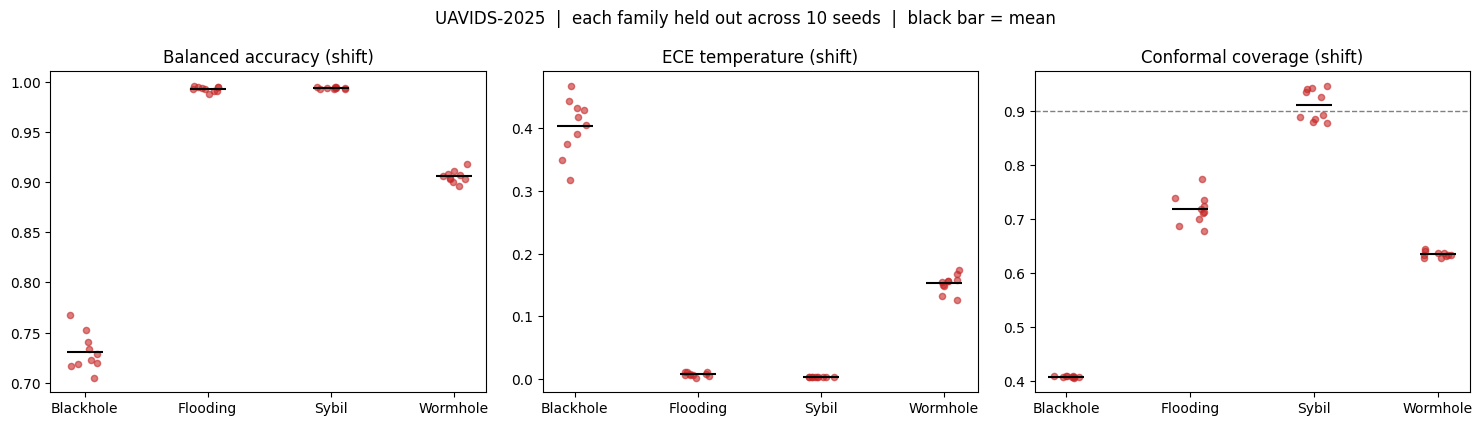

In [10]:
# Figure: per-family spread across seeds (does the ranking hold?)
fams = list(agg.index)
labels = [f.replace(" Attack", "") for f in fams]
panels = [("shift_balacc", "Balanced accuracy (shift)", None),
          ("shift_ECE_temp", "ECE temperature (shift)", None),
          ("shift_coverage", "Conformal coverage (shift)", 1 - CONFIG["conformal_alpha"])]
jit = np.random.default_rng(0)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
for a, (col, title, target) in zip(ax, panels):
    for i, F in enumerate(fams):
        v = raw.loc[raw["held_out"] == F, col].values
        a.scatter(i + jit.uniform(-0.12, 0.12, len(v)), v, s=20, alpha=0.6, color="#c62828")
        a.scatter([i], [v.mean()], marker="_", s=700, color="black", zorder=3)
    a.set_xticks(range(len(fams))); a.set_xticklabels(labels)
    a.set_title(title)
    if target is not None:
        a.axhline(target, ls="--", color="gray", lw=1)
fig.suptitle("UAVIDS-2025  |  each family held out across %d seeds  |  black bar = mean" % len(CONFIG["seeds"]))
fig.tight_layout()
fig.savefig(os.path.join(CONFIG["fig_dir"], "03_seed_spread.png"), dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Commit results (end-of-unit discipline)
!git add reports/ figures/ notebooks/
!git commit -m "03 UAVIDS-2025: multi-family held-out across 10 seeds (mean and std per family, spread figure)"
!git push origin main

[main 2fc2e68] 03 UAVIDS-2025: multi-family held-out across 10 seeds (mean and std per family, spread figure)
 5 files changed, 48 insertions(+), 1 deletion(-)
 create mode 100644 figures/03_seed_spread.png
 create mode 100644 notebooks/03_uavids_seeds.ipynb
 create mode 100644 reports/03_seed_aggregate.csv
 create mode 100644 reports/03_seed_raw.csv
Enumerating objects: 15, done.
Counting objects: 100% (15/15), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10), 124.40 KiB | 3.11 MiB/s, done.
Total 10 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/anasbiswas1/uav-trust-research.git
   57bbd0f..2fc2e68  main -> main
